# 6.4.1 最小二乘与误差假设

## 学习目标与先修知识

能从平方残差（residual）推导普通最小二乘（ordinary least squares，OLS），把正交（orthogonality）条件与矩阵（matrix）满列秩（rank）相连；说明同方差（homoscedasticity）高斯误差（Gaussian error）下的似然（likelihood）关系，并辨认解释变量有误差的限制。

先修：3.2 的矩阵、秩和投影（projection）直觉，5.2 的方差（variance）与独立性，5.3 的似然。[复习条件概率](../../05-随机性与信息/03-条件概率与贝叶斯更新/01-由条件概率推导贝叶斯更新.ipynb)。

## 具体问题

用已知标准浓度（concentration）校准传感器，读数随浓度近似成一条直线。同一批读数通常不能被任何直线同时穿过，我们应该怎样定义“拟合得更好”？一条看起来接近的直线，其斜率（slope）就一定具有物理解释吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
xs=[0.,1.,2.,3.]
ys=[1.1,2.8,5.2,6.9]
rows=[]
for intercept,slope in [(1.,2.),(0.,2.),(1.,1.5)]:
    sse=sum((y-intercept-slope*x)**2 for x,y in zip(xs,ys))
    rows.append((intercept,slope,sse))
display(Markdown(show_table(['截距 / U','斜率 / U·C⁻¹','平方残差和 / U²'],rows)))

| 截距 / U | 斜率 / U·C⁻¹ | 平方残差和 / U² |
| --- | --- | --- |
| 1 | 2 | 0.1 |
| 0 | 2 | 4.1 |
| 1 | 1.5 | 3.5 |

## 模型假设

把固定设计（fixed design）的标准浓度 $x_i$ 视为准确给定，单位 C，传感器读数 $y_i$ 单位 U。模型（model） $y_i=\beta_0+\beta_1x_i+\varepsilon_i$；截距单位 U，斜率 U/C。误差均值为零、相互独立，且方差同为 $\sigma^2$。若进一步假设高斯误差，可得到本节的精确似然表达；仅定义最小平方问题不要求概率（probability）模型。

假定同一线性校准关系适用于这段观测（observation）范围，浓度是已知输入（input），读数是有误差的响应。若标准浓度也带不可忽略的误差，通常 OLS 的无误差解释变量假设失效，需要另建误差模型。

## 数学解释与推导

### 两个参数的方程

对候选参数（parameter） $b_0,b_1$，残差 $r_i=y_i-b_0-b_1x_i$ 是观测减预测；平方残差和（sum of squared errors，SSE）为 $S=\sum_i r_i^2$。分别对两个参数求偏导（partial derivative），最小处满足
$$\sum_i r_i=0,\qquad\sum_i x_i r_i=0.$$
记 $\bar x,\bar y$ 为样本平均，由第一式 $b_0=\bar y-b_1\bar x$，再代回第二式得到
$$\hat\beta_1=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}{S_{xx}},\quad S_{xx}=\sum_i(x_i-\bar x)^2,\quad\hat\beta_0=\bar y-\hat\beta_1\bar x.$$
$S_{xx}>0$ 要求浓度不全相同。若所有 $x_i=c$，读数只能约束 $\beta_0+c\beta_1$，重复再多次也不能仅靠该浓度把两参数分开。

### 为什么这是最小值，而不只是驻点

设计矩阵（design matrix） $X$ 的第 i 行是 $[1,x_i]$，参数向量（vector） $\beta=[\beta_0,\beta_1]^\mathsf T$。上式写成 $X^\mathsf T r=0$：残差与 X 的每一列正交，$X\hat\beta$ 是 y 在列空间上的正交投影（orthogonal projection）。对任何参数改变量 d，
$$\|y-X(\hat\beta+d)\|^2=\|r-Xd\|^2=\|r\|^2+\|Xd\|^2\ge\|r\|^2.$$
X 满列秩时，只有 d=0 可使第二项为零，参数才唯一。公式 $(X^\mathsf TX)\hat\beta=X^\mathsf Ty$ 用于解释；实际一般问题用 `np.linalg.lstsq`，不要显式计算矩阵逆。形成 $X^\mathsf TX$ 还会放大病态程度，本节的中心化标量式更容易检查。

### 从误差密度到损失

固定 X，独立同方差 $\varepsilon_i\sim N(0,\sigma^2)$ 给出
$$L(\beta)=\prod_i\frac1{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_i-X_i\beta)^2}{2\sigma^2}\right],\quad\log L=C-\frac{S}{2\sigma^2}.$$
因此固定正 σ 时最大化似然等于最小化 SSE。这不等于“所有误差都应使用平方损失”；已知不同 $\sigma_i$ 时应按 $1/\sigma_i^2$ 加权，相关误差还涉及非对角协方差（covariance）。仅零均值条件使估计无偏，同方差和独立条件给出常用方差公式，高斯条件才支持本篇的精确高斯区间解释。

拟合后的残差不是原始误差的独立样本：它们必须满足两条正交约束。SSE 衡量当前数据上的拟合；预测能力则用未参与拟合的读数来检查。

## 核心实现

把每个量的计算写在本节，返回普通数值与列表；先检查定义，再用独立关系核对结果。

In [3]:
def fit_line(xs: list[float], ys: list[float]) -> tuple[float, float, list[float]]:
    if len(xs) != len(ys) or len(xs) < 2:
        raise ValueError('至少需要两对观测')
    xmean, ymean = sum(xs)/len(xs), sum(ys)/len(ys)
    sxx = sum((x-xmean)**2 for x in xs)
    if sxx == 0:
        raise ValueError('输入全相同，截距和斜率不能分别估计')
    slope = sum((x-xmean)*(y-ymean) for x,y in zip(xs,ys))/sxx
    intercept = ymean-slope*xmean
    residuals = [y-intercept-slope*x for x,y in zip(xs,ys)]
    return intercept, slope, residuals

## 对照实验

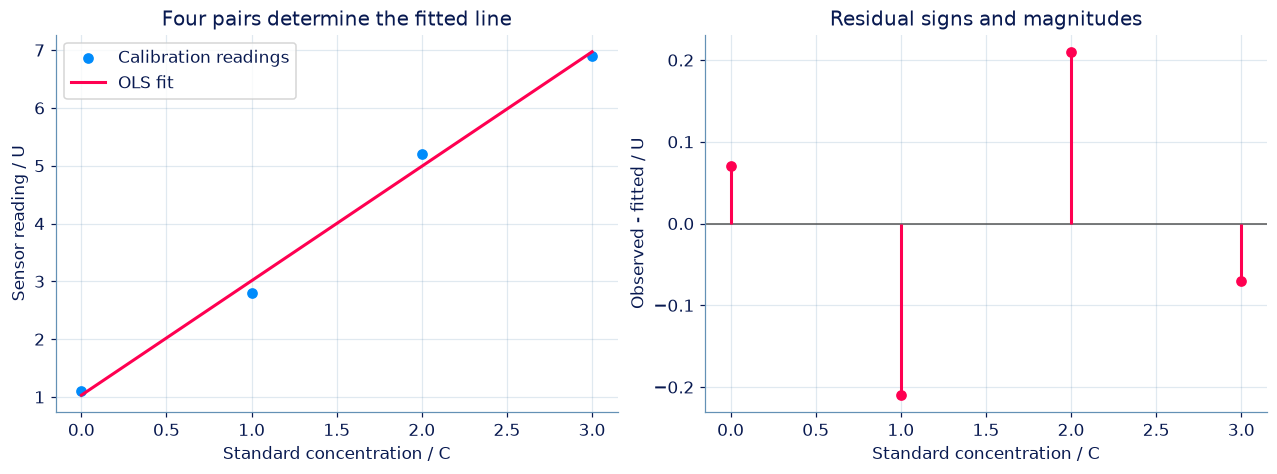

| 截距 / U | 斜率 / U·C⁻¹ | SSE / U² |
| --- | --- | --- |
| 1.03 | 1.98 | 0.098 |

In [4]:
intercept,slope,residuals=fit_line(xs,ys)
grid=np.linspace(0,3,121)
fig,axes=plt.subplots(1,2,figsize=(11.5,4.2))
axes[0].scatter(xs,ys,color=BLUE,label='Calibration readings')
axes[0].plot(grid,intercept+slope*grid,color=PINK,label='OLS fit')
axes[0].set(xlabel='Standard concentration / C',ylabel='Sensor reading / U',title='Four pairs determine the fitted line')
axes[0].legend()
axes[1].axhline(0,color=GRAY,lw=1)
axes[1].vlines(xs,0,residuals,color=PINK)
axes[1].scatter(xs,residuals,color=PINK)
axes[1].set(xlabel='Standard concentration / C',ylabel='Observed - fitted / U',title='Residual signs and magnitudes')
plt.show()
display(Markdown(show_table(['截距 / U','斜率 / U·C⁻¹','SSE / U²'],[(intercept,slope,sum(r*r for r in residuals))])))

## 结果解释

这四个读数的最小二乘截距为 1.03 U、斜率为 1.98 U/C，残差有正有负。残差之和及与浓度的内积（inner product）为零，来自拟合约束；这两个零不是关于误差“已经独立”的统计证据。后续用不同浓度与新的独立读数检验线性校准关系，才能检查本范围外的解释。

### 独立核对与边界

In [5]:
X=np.column_stack([np.ones(len(xs)),xs])
library=np.linalg.lstsq(X,np.asarray(ys),rcond=None)[0]
assert np.allclose(library,[intercept,slope])
assert abs(sum(residuals))<1e-12
assert abs(sum(x*r for x,r in zip(xs,residuals)))<1e-12
assert np.allclose([intercept,slope],[1.03,1.98])
# 同一浓度使两列相关；必须报告不可分别估计，而不是返回任意一对参数。
try:
    fit_line([2.,2.,2.],[4.,5.,6.])
except ValueError as exc:
    display(Markdown(f'边界核对：{exc}。'))
else:
    raise AssertionError('应拒绝秩亏设计')

边界核对：输入全相同，截距和斜率不能分别估计。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：用残差定义直线拟合

拟合 y=β0+β1*x，以未加权平方残差和（sum of squared errors，SSE）最小为目标，返回截距、斜率（slope）与每个残差（residual）。

**函数与代码模板**

```python
def solve(
    xs: list[float],
    ys: list[float],
) -> tuple[float, float, list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `xs` | `list[float]` | 已知且本题不含误差的实验输入（input）。 | U |
| `ys` | `list[float]` | 与xs对应的观测（observation）输出（output）。 | V |

**返回值**

按以下顺序返回元组：(intercept, slope, residuals)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `intercept` | `float` | 截距β0。 | V |
| `slope` | `float` | 斜率β1。 | V/U |
| `residuals` | `list[float]` | 观测减拟合，顺序与输入一致。 | V |

**计算规则**

xbar、ybar为样本均值；Sxx=Σ(x−xbar)²；β1=Σ(x−xbar)(y−ybar)/Sxx，β0=ybar−β1*xbar；残差=y−β0−β1*x。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 等长2—50点；绝对值≤100；Sxx≥1e−6。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| xs | 已知且本题不含误差的实验输入（input）。 | [0.0, 1.0, 2.0] | U |
| ys | 与xs对应的观测（observation）输出（output）。 | [1.0, 3.0, 5.0] | V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
xs = [0.0, 1.0, 2.0]
ys = [1.0, 3.0, 5.0]

result = solve(xs, ys)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| intercept | 截距β0。 | 1 | V |
| slope | 斜率β1。 | 2 | V/U |
| residuals | 观测减拟合，顺序与输入一致。 | [0.0, 0.0, 0.0] | V |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 2.0, [0.0, 0.0, 0.0])
```

**样例解释**

三个点恰好在 y=1+2x 上，返回截距1 V、斜率2 V/U和三个零残差。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：用残差定义直线拟合](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-line-fit)

### 第 2 题 · 多项选择题：平方残差何时对应似然

固定设计（fixed design）矩阵（matrix）X，y=Xβ+ε，共同误差方差（variance）σ²>0，且最小平方残差和（sum of squared errors，SSE）严格大于0。哪些前提支持普通最小二乘（ordinary least squares，OLS）与最大似然（likelihood）的对应？

- **A.** 任意异方差误差仍应无条件使用同样权重。
- **B.** 共同方差（homoscedasticity）已知或未知时，β的最大似然点估计都可由最小SSE给出。
- **C.** 平方残差（residual）最小就说明模型（model）机制正确。
- **D.** ε各项独立、均值0，服从共同方差的高斯分布（Gaussian distribution）。

[作答：平方残差何时对应似然](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-least-squares-gaussian)

### 第 3 题 · 单项选择题：输入恒定时哪些系数可确定

所有x都等于2，拟合y=β0+β1*x。哪项正确？

- **A.** 增加同样x的重复就一定恢复满列秩（rank）。
- **B.** 直接求逆可以创造缺少的信息。
- **C.** 两个系数分别唯一可定。
- **D.** 只有组合β0+2β1能由这些观测（observation）约束，设计矩阵（design matrix）列相关。

[作答：输入恒定时哪些系数可确定](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-rank-deficiency)

### 第 4 题 · 多项选择题：最小二乘残差的代数检查

设计矩阵（design matrix）满列秩（rank）、包含截距，使用无约束普通最小二乘（ordinary least squares，OLS）。哪些成立？

- **A.** 残差（residual）与所有未观测（observation）的真实机制都独立。
- **B.** Xᵀr=0到数值误差（numerical error）范围内。
- **C.** 残差和为0到数值误差范围内。
- **D.** 每个残差都必须为0。

[作答：最小二乘残差的代数检查](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-orthogonal-residual)

### 第 5 题 · 单项选择题：不同测量精度如何进入损失

独立高斯误差（Gaussian error）标准差（standard deviation）为σᵢ，且均已知。哪项正确？

- **A.** 用Σrᵢ²/σᵢ²作为与似然（likelihood）相关的损失。
- **B.** 标准差越大，权重应越大。
- **C.** 所有残差（residual）先取绝对值再平方会改成不同损失。
- **D.** 误差分布（distribution）和测量精度与估计无关。

[作答：不同测量精度如何进入损失](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-weighted-errors)

**进一步阅读**

[NIST：最小二乘](https://www.itl.nist.gov/div898/handbook/pmd/section4/pmd431.htm)：直线参数与残差尺度。正文给出投影恒等式和独立线性代数核对；校准数据为手工教学例子。